# Part 4 — Prediction Modeling & Evaluation

**Owner**: A Dang dep zai

**Inputs**:
- `climate_anomaly_features.parquet` (Khiem)
- `flunet_clean.parquet` (Phong)
- `mobility_features.parquet` (Hieu)
- `graph_metrics.parquet` (Khiem)

**MoMD Algorithms**: Reservoir Sampling · Flajolet-Martin · Welford Streaming · Johnson-Lindenstrauss

**Models**: Ridge Regression (baseline) · Gradient Boosting (enhanced) · Enhanced + JL projection, LazyPredict

**Outputs**: model results, per-country predictions, risk ranking, outbreak detection metrics

In [7]:
#!pip install scikit-learn xgboost pyarrow matplotlib seaborn lazypredict -q

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import hashlib, math
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import warnings; warnings.filterwarnings('ignore')

CLIMATE_IN  = '/kaggle/input/notebooks/khimnguynth/notebook-2-minhash-lsh/climate_anomaly_features.parquet'
FLUNET_IN   = '/kaggle/input/notebooks/phongngtun/infuenza-era5-processing/flunet_clean.parquet'
MOBILITY_IN = '/kaggle/input/notebooks/b22dccn320trnminhhiu/notebook-3-pagerank/mobility_features.parquet'
GRAPH_IN    = '/kaggle/input/notebooks/b22dccn320trnminhhiu/notebook-3-pagerank/graph_metrics.parquet'
OUTPUT_DIR  = '/kaggle/working/'

climate  = pd.read_parquet(CLIMATE_IN)
flunet   = pd.read_parquet(FLUNET_IN)
mobility = pd.read_parquet(MOBILITY_IN)
graph    = pd.read_parquet(GRAPH_IN)

for df_ in [climate, flunet, mobility]:
    df_['year'] = pd.to_numeric(df_['year'], errors='coerce')
    df_['week'] = pd.to_numeric(df_['week'], errors='coerce')
    df_['country_iso3'] = df_['country_iso3'].astype(str).str.strip()

print(f'climate:  {climate.shape}')
print(f'flunet:   {flunet.shape}')
print(f'mobility: {mobility.shape}')
print(f'graph:    {graph.shape}')

climate:  (11960, 33)
flunet:   (25228, 6)
mobility: (16952, 4)
graph:    (214, 8)


## 4.1 MoMD Algorithms

In [9]:
# ── Reservoir Sampling (Algorithm R, MoMD Ch.4)
def reservoir_sample(iterator, k, seed=42):
    rng = np.random.RandomState(seed)
    res = []
    for i, item in enumerate(iterator):
        if i < k: res.append(item)
        else:
            j = rng.randint(0, i+1)
            if j < k: res[j] = item
    return res

# ── Flajolet-Martin (MoMD Ch.4)
class FlajoletMartin:
    def __init__(self, n_groups=7, n_per_group=7, seed=42):
        self.g, self.pg = n_groups, n_per_group
        total = n_groups * n_per_group
        rng = np.random.RandomState(seed)
        p = (1<<31)-1
        self.a, self.b, self.p = rng.randint(1,p,total), rng.randint(0,p,total), p
        self.max_tz = np.zeros(total, dtype=int)
    def _tz(self, x):
        if x==0: return 32
        c=0
        while x&1==0: c+=1; x>>=1
        return c
    def process(self, s):
        x = int(hashlib.sha1(s.encode()).hexdigest(),16) % self.p
        for i in range(len(self.a)):
            h = (self.a[i]*x+self.b[i])%self.p
            self.max_tz[i] = max(self.max_tz[i], self._tz(h))
    def estimate(self):
        est = 2**self.max_tz
        return int(np.median(est.reshape(self.g,self.pg).mean(axis=1)))

# ── Welford Online Stats (streaming normalization)
class WelfordOnline:
    def __init__(self, d):
        self.n, self.mean, self.M2 = 0, np.zeros(d), np.zeros(d)
    def update(self, x):
        x = np.where(np.isnan(x), self.mean, x)
        self.n += 1
        d = x - self.mean; self.mean += d/self.n
        self.M2 += d*(x-self.mean)
    @property
    def std(self): return np.sqrt(self.M2/max(self.n-1,1))
    def normalize(self, x): return (x-self.mean)/np.where(self.std==0,1,self.std)

# ── Johnson-Lindenstrauss projection
def jl_project(X, eps=0.25, seed=42):
    n, d = X.shape
    k = min(d, math.ceil(4*math.log(n)/(eps**2/2 - eps**3/3)))
    rng = np.random.RandomState(seed)
    R = rng.choice([-1,0,0,0,0,1], size=(k,d)).astype(float) * math.sqrt(3)
    return (X @ R.T) / math.sqrt(k), R

print('MoMD algorithms loaded ✓')

# FM: count distinct outbreak events
flu_threshold = float(flunet['flu_cases_total'].median())
fm = FlajoletMartin()
outbreak_df = flunet[flunet['flu_cases_total'] > flu_threshold]
for _, r in outbreak_df.iterrows():
    fm.process(f"{r['country_iso3']}_{int(r['year'])}_{int(r['week'])}")
exact_distinct = outbreak_df[['country_iso3','year','week']].drop_duplicates().shape[0]
print(f'\nFlajolet-Martin distinct outbreak events:')
print(f'  Exact:    {exact_distinct:,}')
print(f'  FM est:   {fm.estimate():,}')
print(f'  Error:    {abs(exact_distinct-fm.estimate())/exact_distinct*100:.1f}%')

MoMD algorithms loaded ✓

Flajolet-Martin distinct outbreak events:
  Exact:    9,630
  FM est:   14,043
  Error:    45.8%


## 4.2 Build Master Feature Table

In [10]:
flu = flunet[['country_iso3','year','week','flu_cases_total']].copy()
flu['flu_cases_total'] = pd.to_numeric(flu['flu_cases_total'], errors='coerce').fillna(0)
flu = flu.sort_values(['country_iso3','year','week'])
flu['flu_target_t2'] = flu.groupby('country_iso3')['flu_cases_total'].shift(-2)

anomaly_cols = [c for c in climate.columns if '_anomaly' in c and 'lag' not in c]
lag_cols     = [c for c in climate.columns if '_lag' in c]
graph_cols   = [c for c in ['pagerank_score','tspr_score','betweenness','degree_centrality','route_strength'] if c in graph.columns]

df_master = (
    flu
    .merge(climate, on=['country_iso3','year','week'], how='inner')
    .merge(mobility[['country_iso3','year','week','mob_weighted_neighbor_flu']], on=['country_iso3','year','week'], how='left')
    .merge(graph[['country_iso3']+graph_cols], on='country_iso3', how='left')
    .dropna(subset=['flu_target_t2'])
)

FEAT_BASE = [c for c in anomaly_cols + lag_cols if c in df_master.columns]
FEAT_ENH  = FEAT_BASE + [c for c in ['mob_weighted_neighbor_flu','flu_cases_total']+graph_cols if c in df_master.columns]
TARGET    = 'flu_target_t2'

print(f'Master table: {df_master.shape}')
print(f'Countries: {df_master["country_iso3"].nunique()}')
print(f'Baseline features: {len(FEAT_BASE)}')
print(f'Enhanced features: {len(FEAT_ENH)}')
print(f'\nTarget (flu_cases t+2) distribution:')
print(df_master[TARGET].describe().round(2).to_string())

Master table: (14279, 41)
Countries: 103
Baseline features: 19
Enhanced features: 26

Target (flu_cases t+2) distribution:
count    14279.00
mean        78.86
std        477.04
min          0.00
25%          0.00
50%          3.00
75%         21.00
max      14624.00


In [11]:
# Reservoir sample for fallback test split (MoMD)
flu_stream = df_master.to_dict('records')
k_test = max(500, len(flu_stream)//5)
test_sample = reservoir_sample(iter(flu_stream), k=k_test)
test_keys = {(r['country_iso3'], r['year'], r['week']) for r in test_sample}

def prepare_train_val_test(df, feats, target, test_keys):
    sub = df[feats + [target, 'country_iso3', 'year', 'week']].dropna().copy()
    sub = sub.sort_values(['year', 'week', 'country_iso3']).reset_index(drop=True)

    # Primary split: holdout test is year 2025
    test = sub[sub['year'] == 2025].copy()
    tv = sub[sub['year'] < 2025].copy()

    # Fallback if 2025 is sparse: reservoir-based test split
    if len(test) < 50 or len(tv) < 200:
        mask = sub.apply(lambda r: (r['country_iso3'], r['year'], r['week']) in test_keys, axis=1)
        test = sub[mask].copy()
        tv = sub[~mask].copy()

    # Validation is the latest 20% block in train+val timeline (walk-forward style)
    split_idx = int(len(tv) * 0.8)
    split_idx = max(split_idx, 1)
    split_idx = min(split_idx, len(tv) - 1)
    train = tv.iloc[:split_idx].copy()
    val = tv.iloc[split_idx:].copy()

    sc = StandardScaler()
    Xtr = sc.fit_transform(train[feats].values)
    Xva = sc.transform(val[feats].values)
    Xte = sc.transform(test[feats].values)

    return (
        Xtr, train[target].values,
        Xva, val[target].values,
        Xte, test[target].values,
        train, val, test, sc
    )

(Xtr_b, ytr_b, Xva_b, yva_b, Xte_b, yte_b, tr_b, va_b, te_b, sc_b) = prepare_train_val_test(
    df_master, FEAT_BASE, TARGET, test_keys
)
(Xtr_e, ytr_e, Xva_e, yva_e, Xte_e, yte_e, tr_e, va_e, te_e, sc_e) = prepare_train_val_test(
    df_master, FEAT_ENH, TARGET, test_keys
)

# JL projection learned from train only, then applied to val/test
Xtr_jl, R_jl = jl_project(Xtr_e, eps=0.25)
Xva_jl = (Xva_e @ R_jl.T) / math.sqrt(R_jl.shape[0])
Xte_jl = (Xte_e @ R_jl.T) / math.sqrt(R_jl.shape[0])

print(f'Baseline split sizes  -> train: {len(ytr_b):,} | val: {len(yva_b):,} | test: {len(yte_b):,}')
print(f'Enhanced split sizes  -> train: {len(ytr_e):,} | val: {len(yva_e):,} | test: {len(yte_e):,}')
print(f'Enhanced features: {Xtr_e.shape[1]}D -> JL projected: {Xtr_jl.shape[1]}D')

Baseline split sizes  -> train: 5,249 | val: 1,313 | test: 6,608
Enhanced split sizes  -> train: 5,036 | val: 1,259 | test: 6,293
Enhanced features: 26D -> JL projected: 26D


## 4.3 Model Training & Evaluation

In [12]:
trained_models = {}

def build_candidates(algo):
    if algo == 'ridge':
        return [Ridge(alpha=a) for a in [0.1, 1.0, 5.0, 10.0]]
    return [
        GradientBoostingRegressor(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42
        ),
        GradientBoostingRegressor(
            n_estimators=250, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42
        ),
        GradientBoostingRegressor(
            n_estimators=300, max_depth=3, learning_rate=0.03,
            subsample=0.9, min_samples_leaf=3, random_state=42
        ),
    ]

def train_eval(Xtr, ytr, Xva, yva, Xte, yte, algo, label):
    # Model selection on validation split
    candidates = build_candidates(algo)
    best_model, best_val_rmse = None, np.inf
    for cand in candidates:
        cand.fit(Xtr, ytr)
        val_pred = np.maximum(cand.predict(Xva), 0)
        val_rmse = root_mean_squared_error(yva, val_pred)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model = cand

    # Refit best config on train+val, evaluate once on test
    X_fit = np.vstack([Xtr, Xva])
    y_fit = np.concatenate([ytr, yva])
    best_model.fit(X_fit, y_fit)
    pred = np.maximum(best_model.predict(Xte), 0)

    mae = mean_absolute_error(yte, pred)
    rmse = root_mean_squared_error(yte, pred)
    r2 = r2_score(yte, pred)

    # Outbreak detection (binary: flu > median threshold on fit set)
    thresh = float(np.median(y_fit[y_fit > 0])) if (y_fit > 0).any() else 1.0
    y_bin_true = (yte > thresh).astype(int)
    y_bin_pred = (pred > thresh).astype(int)
    prec = precision_score(y_bin_true, y_bin_pred, zero_division=0)
    rec = recall_score(y_bin_true, y_bin_pred, zero_division=0)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)

    key = f'{algo}_{label}'
    trained_models[key] = {
        'model': best_model, 'pred': pred, 'actual': yte,
        'y_bin_true': y_bin_true, 'y_bin_pred': y_bin_pred,
        'thresh': thresh, 'Xte': Xte, 'test_df': None
    }

    print(f'  [{key:30s}]  ValRMSE={best_val_rmse:8.1f}  MAE={mae:8.1f}  RMSE={rmse:8.1f}  R2={r2:6.4f}  '
          f'Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}')

    return {
        'model': key, 'algorithm': algo, 'features': label,
        'Val_RMSE': round(float(best_val_rmse), 3),
        'MAE': round(float(mae), 3), 'RMSE': round(float(rmse), 3), 'R2': round(float(r2), 4),
        'Precision': round(float(prec), 3), 'Recall': round(float(rec), 3), 'F1': round(float(f1), 3),
        'n_test': len(yte)
    }

print('=== MODEL TRAINING (train/val/test pipeline) ===' + '=' * 20)
print(f'  {"Model":30s}  {"ValRMSE":>9s}  {"MAE":>9s}  {"RMSE":>9s}  {"R2":>7s}  '
      f'{"Prec":>7s}  {"Rec":>7s}  {"F1":>7s}')
print('  ' + '-' * 105)

all_results = []
for algo in ['ridge', 'gbm']:
    all_results.append(train_eval(Xtr_b, ytr_b, Xva_b, yva_b, Xte_b, yte_b, algo, 'baseline'))
    all_results.append(train_eval(Xtr_e, ytr_e, Xva_e, yva_e, Xte_e, yte_e, algo, 'enhanced'))
    all_results.append(train_eval(Xtr_jl, ytr_e, Xva_jl, yva_e, Xte_jl, yte_e, algo, 'enhanced_jl'))

results_df = pd.DataFrame(all_results)
# Store test_df reference for downstream charts
for k in trained_models:
    trained_models[k]['test_df'] = te_e if 'enhanced' in k else te_b

=== MODEL TRAINING (train/val/test pipeline) =======================
  Model                             ValRMSE        MAE       RMSE       R2     Prec      Rec       F1
  ---------------------------------------------------------------------------------------------------------
  [ridge_baseline                ]  ValRMSE=   569.6  MAE=   126.5  RMSE=   568.2  R2=-0.0095  Prec=0.376  Rec=0.996  F1=0.545
  [ridge_enhanced                ]  ValRMSE=   285.9  MAE=    36.7  RMSE=   193.9  R2=0.8878  Prec=0.679  Rec=0.847  F1=0.754
  [ridge_enhanced_jl             ]  ValRMSE=   286.0  MAE=    36.7  RMSE=   193.9  R2=0.8878  Prec=0.679  Rec=0.847  F1=0.753
  [gbm_baseline                  ]  ValRMSE=   575.0  MAE=   126.5  RMSE=   567.7  R2=-0.0075  Prec=0.375  Rec=0.986  F1=0.543
  [gbm_enhanced                  ]  ValRMSE=   312.5  MAE=    38.4  RMSE=   209.8  R2=0.8688  Prec=0.854  Rec=0.881  F1=0.868
  [gbm_enhanced_jl               ]  ValRMSE=   329.0  MAE=    71.5  RMSE=   274.0  R2=0.7

## 4.4 Results Overview — Comprehensive Plot

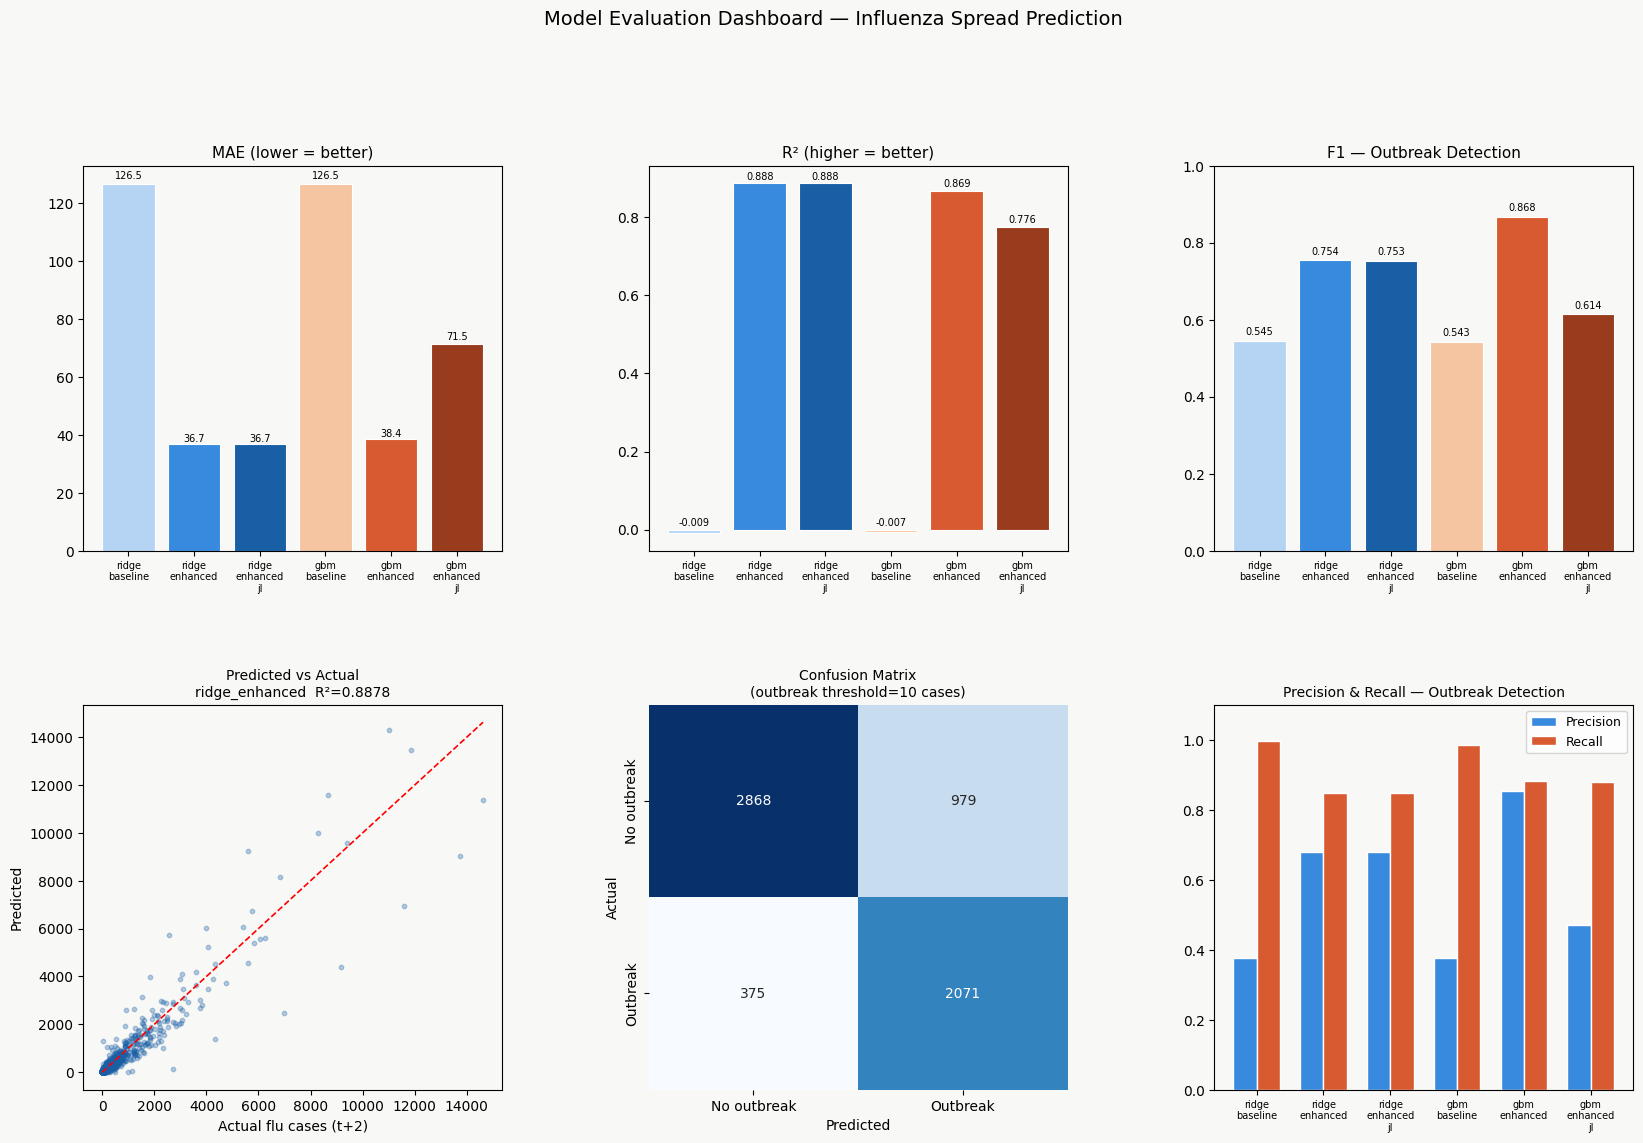

✓ Saved model_dashboard.png  (best model: ridge_enhanced)


In [13]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

color_map = {
    'ridge_baseline':    '#B5D4F4',
    'ridge_enhanced':    '#378ADD',
    'ridge_enhanced_jl': '#185FA5',
    'gbm_baseline':      '#F5C4A0',
    'gbm_enhanced':      '#D85A30',
    'gbm_enhanced_jl':   '#993C1D',
}
colors = [color_map.get(m, '#888') for m in results_df['model']]
labels = results_df['model'].str.replace('_', '\n')

# ─ MAE
ax1 = fig.add_subplot(gs[0,0])
bars = ax1.bar(range(len(results_df)), results_df['MAE'], color=colors, edgecolor='white', linewidth=0.8)
ax1.set_xticks(range(len(results_df))); ax1.set_xticklabels(labels, fontsize=7)
ax1.set_title('MAE (lower = better)', fontsize=11)
for b, v in zip(bars, results_df['MAE']): ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01*b.get_height(), f'{v:.1f}', ha='center', va='bottom', fontsize=7)
ax1.set_facecolor('#f8f8f6')

# ─ R²
ax2 = fig.add_subplot(gs[0,1])
bars = ax2.bar(range(len(results_df)), results_df['R2'], color=colors, edgecolor='white', linewidth=0.8)
ax2.set_xticks(range(len(results_df))); ax2.set_xticklabels(labels, fontsize=7)
ax2.set_title('R² (higher = better)', fontsize=11)
for b, v in zip(bars, results_df['R2']): ax2.text(b.get_x()+b.get_width()/2, max(b.get_height()+0.005,0.005), f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax2.set_facecolor('#f8f8f6')

# ─ F1 (outbreak detection)
ax3 = fig.add_subplot(gs[0,2])
bars = ax3.bar(range(len(results_df)), results_df['F1'], color=colors, edgecolor='white', linewidth=0.8)
ax3.set_xticks(range(len(results_df))); ax3.set_xticklabels(labels, fontsize=7)
ax3.set_title('F1 — Outbreak Detection', fontsize=11)
ax3.set_ylim(0, 1)
for b, v in zip(bars, results_df['F1']): ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax3.set_facecolor('#f8f8f6')

# ─ Best model: Predicted vs Actual scatter
best_key = results_df.loc[results_df['R2'].idxmax(), 'model']
best = trained_models[best_key]
ax4 = fig.add_subplot(gs[1,0])
ax4.scatter(best['actual'], best['pred'], alpha=0.3, s=10, color='#185FA5')
mx = max(best['actual'].max(), best['pred'].max())
ax4.plot([0,mx],[0,mx], 'r--', linewidth=1.2)
ax4.set_xlabel('Actual flu cases (t+2)'); ax4.set_ylabel('Predicted')
r2_best = results_df.loc[results_df['model']==best_key,'R2'].values[0]
ax4.set_title(f'Predicted vs Actual\n{best_key}  R²={r2_best:.4f}', fontsize=10)
ax4.set_facecolor('#f8f8f6')

# ─ Confusion matrix (best model outbreak detection)
ax5 = fig.add_subplot(gs[1,1])
cm_vals = confusion_matrix(best['y_bin_true'], best['y_bin_pred'])
sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['No outbreak','Outbreak'], yticklabels=['No outbreak','Outbreak'],
            cbar=False)
ax5.set_title(f'Confusion Matrix\n(outbreak threshold={best["thresh"]:.0f} cases)', fontsize=10)
ax5.set_xlabel('Predicted'); ax5.set_ylabel('Actual')

# ─ Precision / Recall comparison
ax6 = fig.add_subplot(gs[1,2])
x = np.arange(len(results_df))
w = 0.35
ax6.bar(x-w/2, results_df['Precision'], w, label='Precision', color='#378ADD', edgecolor='white')
ax6.bar(x+w/2, results_df['Recall'],    w, label='Recall',    color='#D85A30', edgecolor='white')
ax6.set_xticks(x); ax6.set_xticklabels(labels, fontsize=7)
ax6.set_title('Precision & Recall — Outbreak Detection', fontsize=10)
ax6.set_ylim(0, 1.1); ax6.legend(fontsize=9)
ax6.set_facecolor('#f8f8f6')

for ax in [ax1,ax2,ax3,ax4,ax5,ax6]: ax.figure.patch.set_facecolor('#f8f8f6')
fig.suptitle('Model Evaluation Dashboard — Influenza Spread Prediction', fontsize=14, y=1.01)
plt.savefig(OUTPUT_DIR+'model_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved model_dashboard.png  (best model: {best_key})')

## 4.5 Per-Country Prediction Time Series

Show actual vs predicted flu cases over time for selected countries.

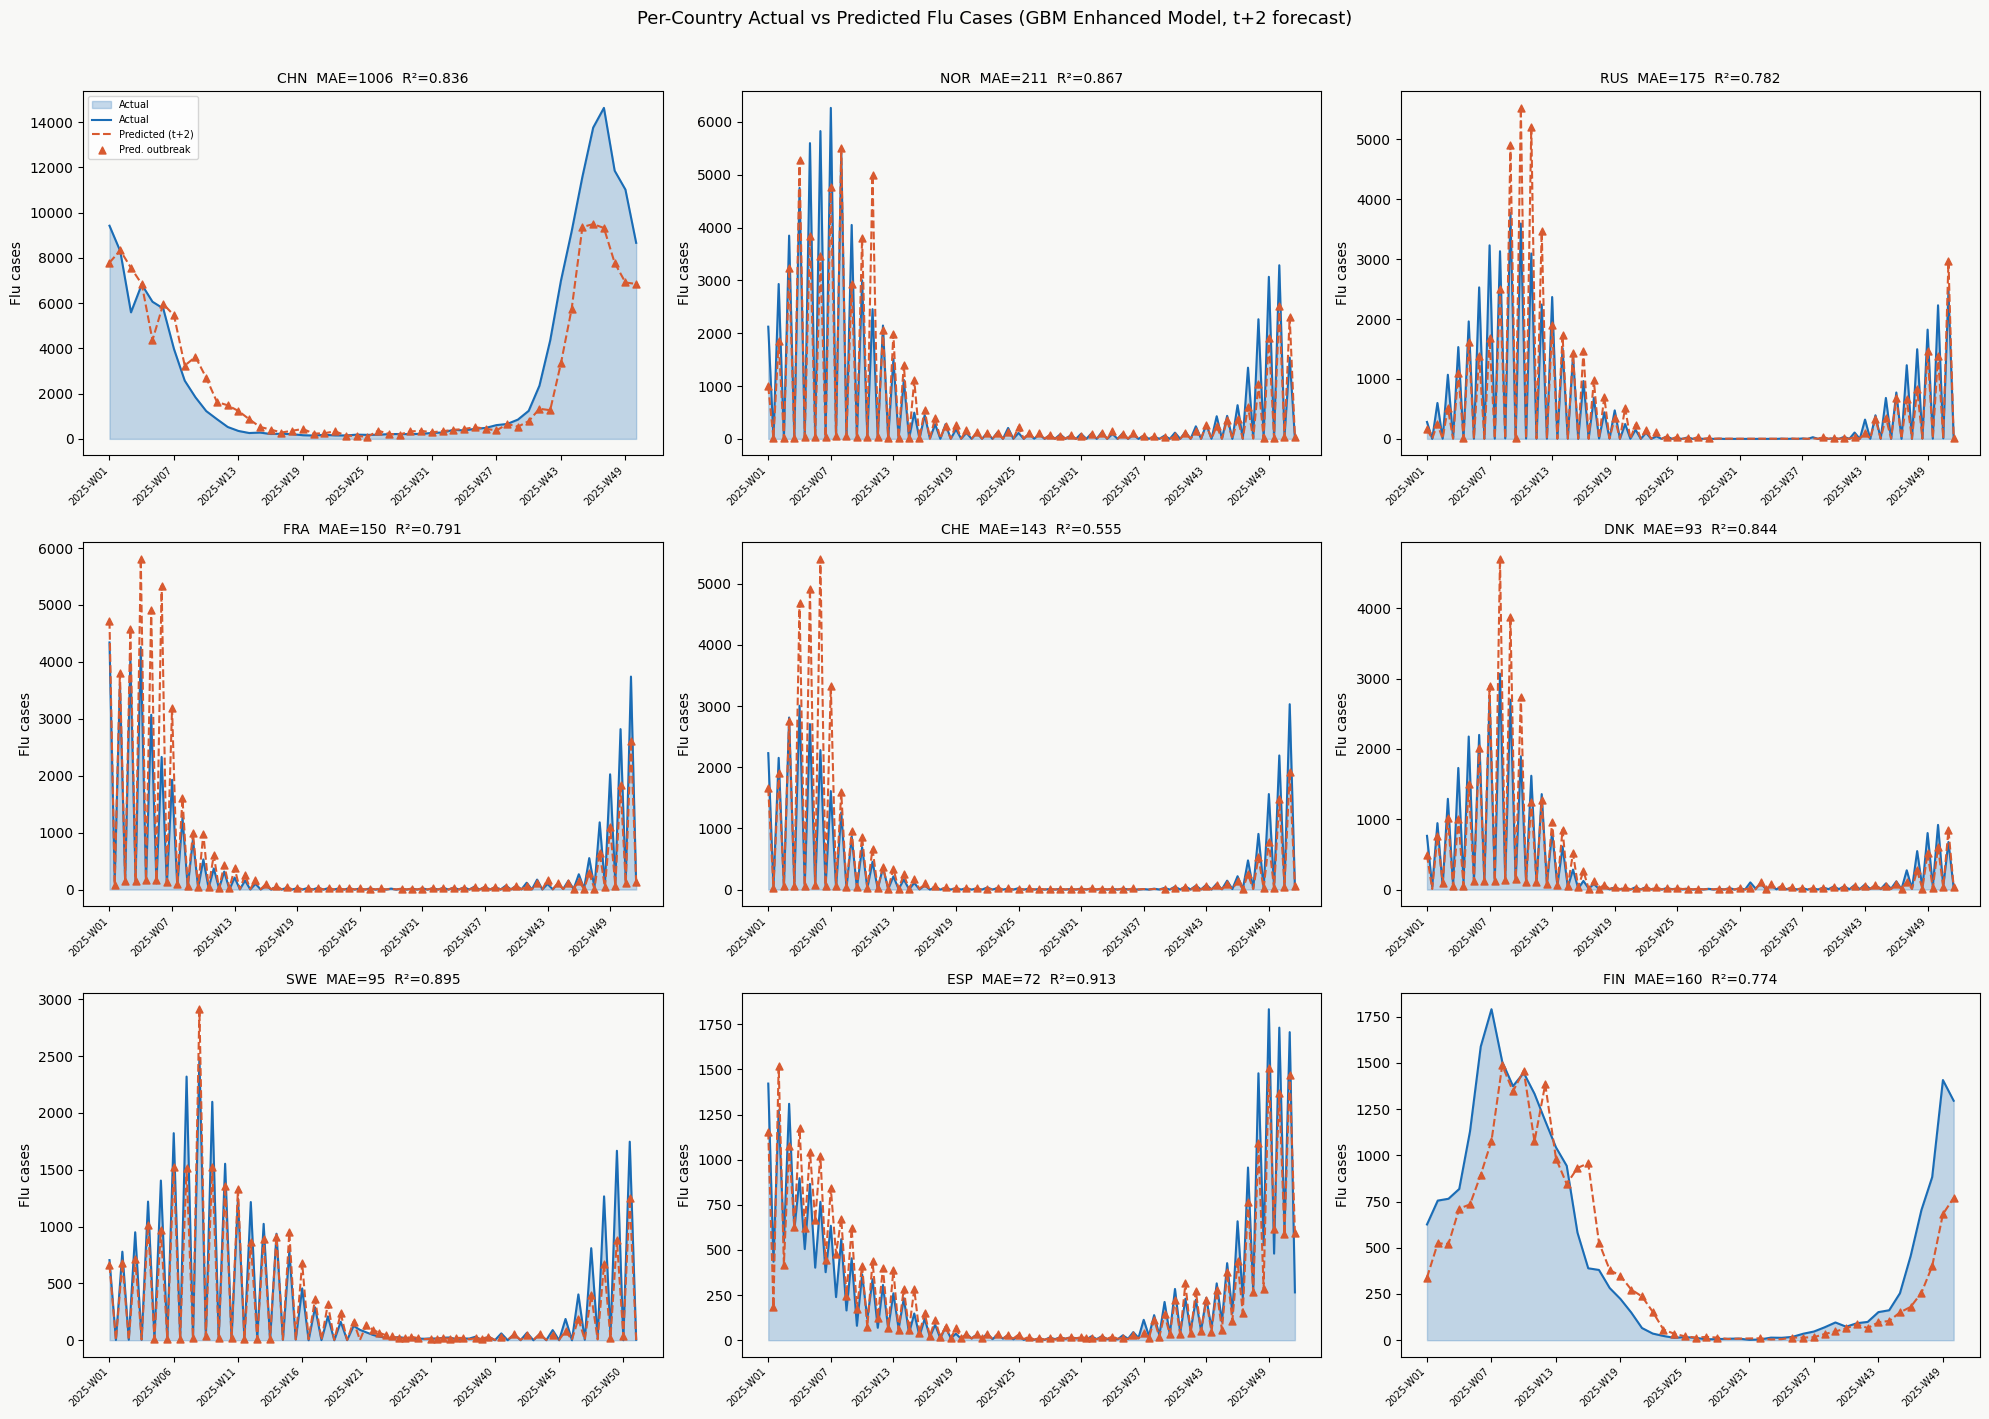

✓ Saved per_country_predictions.png  (9 countries)


In [14]:
# Use the best GBM enhanced model for per-country plots
best_gbm_key = results_df.loc[(results_df['algorithm']=='gbm')&(results_df['features']=='enhanced'), 'model'].values
best_gbm_key = best_gbm_key[0] if len(best_gbm_key) > 0 else best_key
best_gbm = trained_models[best_gbm_key]

# Attach predictions back to test dataframe
test_with_pred = best_gbm['test_df'].copy()
test_with_pred = test_with_pred.iloc[:len(best_gbm['pred'])].copy()
test_with_pred['pred_flu_t2']  = best_gbm['pred']
test_with_pred['actual_flu_t2'] = best_gbm['actual']
test_with_pred['residual']     = test_with_pred['actual_flu_t2'] - test_with_pred['pred_flu_t2']

# Select countries with most data points AND high flu burden
country_stats = test_with_pred.groupby('country_iso3').agg(
    n_weeks=('actual_flu_t2','count'),
    total_flu=('actual_flu_t2','sum'),
    mae_country=('residual', lambda x: x.abs().mean())
).query('n_weeks >= 10').nlargest(9, 'total_flu').index.tolist()

if not country_stats:
    # fallback: just take whichever countries have most records
    country_stats = test_with_pred.groupby('country_iso3').size().nlargest(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharey=False)
axes = axes.ravel()

for ax, country in zip(axes, country_stats):
    cdf = test_with_pred[test_with_pred['country_iso3']==country].sort_values(['year','week'])
    x   = np.arange(len(cdf))
    xlabels = cdf['year'].astype(str) + '-W' + cdf['week'].astype(str).str.zfill(2)

    ax.fill_between(x, 0, cdf['actual_flu_t2'], alpha=0.25, color='#1A6CB5', label='Actual')
    ax.plot(x, cdf['actual_flu_t2'], color='#1A6CB5', linewidth=1.5, label='Actual')
    ax.plot(x, cdf['pred_flu_t2'],   color='#D85A30', linewidth=1.5,
            linestyle='--', label='Predicted (t+2)')

    # Mark predicted outbreak weeks
    thresh = best_gbm['thresh']
    outbreak_mask = cdf['pred_flu_t2'] > thresh
    ax.scatter(x[outbreak_mask], cdf['pred_flu_t2'][outbreak_mask],
               color='#D85A30', zorder=5, s=25, marker='^', label='Pred. outbreak')

    mae_c = cdf['residual'].abs().mean()
    r2_c  = r2_score(cdf['actual_flu_t2'], cdf['pred_flu_t2']) if len(cdf) > 1 else float('nan')

    tick_step = max(1, len(x)//8)
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(xlabels.iloc[::tick_step], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{country}  MAE={mae_c:.0f}  R²={r2_c:.3f}', fontsize=10)
    ax.set_ylabel('Flu cases')
    ax.set_facecolor('#f8f8f6')
    if country == country_stats[0]:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Per-Country Actual vs Predicted Flu Cases (GBM Enhanced Model, t+2 forecast)',
             fontsize=13, y=1.01)
fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'per_country_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved per_country_predictions.png  ({len(country_stats)} countries)')

## 4.6 Lag Effect Analysis

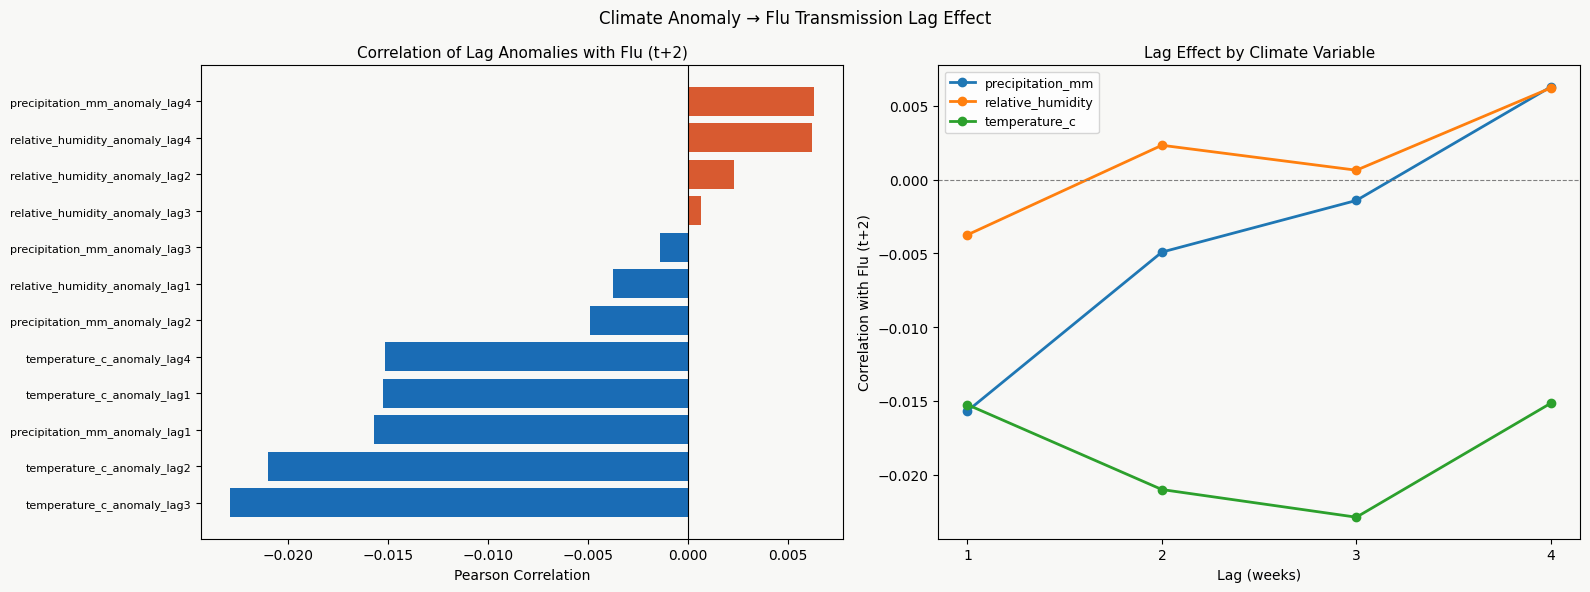

✓ Saved lag_effect_analysis.png

Strongest lag per climate variable:
  precipitation_mm      lag=1   r=-0.0157
  relative_humidity     lag=4   r=0.0062
  temperature_c         lag=3   r=-0.0229


In [15]:
lag_anomaly_cols = [c for c in df_master.columns if '_anomaly_lag' in c]

if lag_anomaly_cols:
    corr_data = df_master[lag_anomaly_cols + [TARGET]].dropna()
    lag_corrs = corr_data.corr()[TARGET].drop(TARGET).dropna()

    # Parse lag number and variable for grouped plot
    parsed = []
    for col, val in lag_corrs.items():
        parts = col.split('_lag')
        if len(parts) == 2:
            parsed.append({
                'col': col, 
                'variable': str(parts[0].replace('_anomaly','')), 
                'lag': int(parts[1]), 
                'corr': float(val)
            })
    parsed_df = pd.DataFrame(parsed)

    if not parsed_df.empty:
        # Use a consistent background color
        bg_color = '#f8f8f6'
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=bg_color)

        # Left: all lag correlations sorted
        sorted_corrs = lag_corrs.sort_values()
        colors = ['#D85A30' if c > 0 else '#1A6CB5' for c in sorted_corrs.values]
        axes[0].barh(sorted_corrs.index, sorted_corrs.values, color=colors)
        axes[0].axvline(0, color='black', linewidth=0.8)
        axes[0].set_title('Correlation of Lag Anomalies with Flu (t+2)', fontsize=11)
        axes[0].set_xlabel('Pearson Correlation')
        axes[0].set_facecolor(bg_color)
        axes[0].tick_params(axis='y', labelsize=8)

        # Right: lag effect by variable and lag number
        for var, grp in parsed_df.groupby('variable'):
            grp_s = grp.sort_values('lag')
            axes[1].plot(grp_s['lag'], grp_s['corr'], marker='o', linewidth=2, label=str(var))
        
        axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
        axes[1].set_xlabel('Lag (weeks)')
        axes[1].set_ylabel('Correlation with Flu (t+2)')
        axes[1].set_title('Lag Effect by Climate Variable', fontsize=11)
        axes[1].legend(fontsize=9)
        axes[1].set_facecolor(bg_color)
        axes[1].set_xticks(sorted(parsed_df['lag'].unique()))

        plt.suptitle('Climate Anomaly → Flu Transmission Lag Effect', fontsize=12)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR + 'lag_effect_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✓ Saved lag_effect_analysis.png')

        # --- SAFER PRINTING SECTION ---
        print('\nStrongest lag per climate variable:')
        for var, grp in parsed_df.groupby('variable'):
            # Find index of max absolute correlation
            idx = grp['corr'].abs().idxmax()
            # Extract row and force values to standard Python types
            best_row = grp.loc[idx]
            
            # If multiple rows have same correlation, loc returns a DataFrame
            if isinstance(best_row, pd.DataFrame):
                best_row = best_row.iloc[0]

            v_name = str(var)
            v_lag  = int(best_row['lag'])
            v_corr = float(best_row['corr'])
            
            # Formatting as a simple string first to avoid any method.__format__ issues
            output_line = "  {:20s}  lag={:<2d}  r={:.4f}".format(v_name, v_lag, v_corr)
            print(output_line)
else:
    print('No lag anomaly columns — check Part 2 output')

## 4.7 Feature Importance (GBM Enhanced Model)

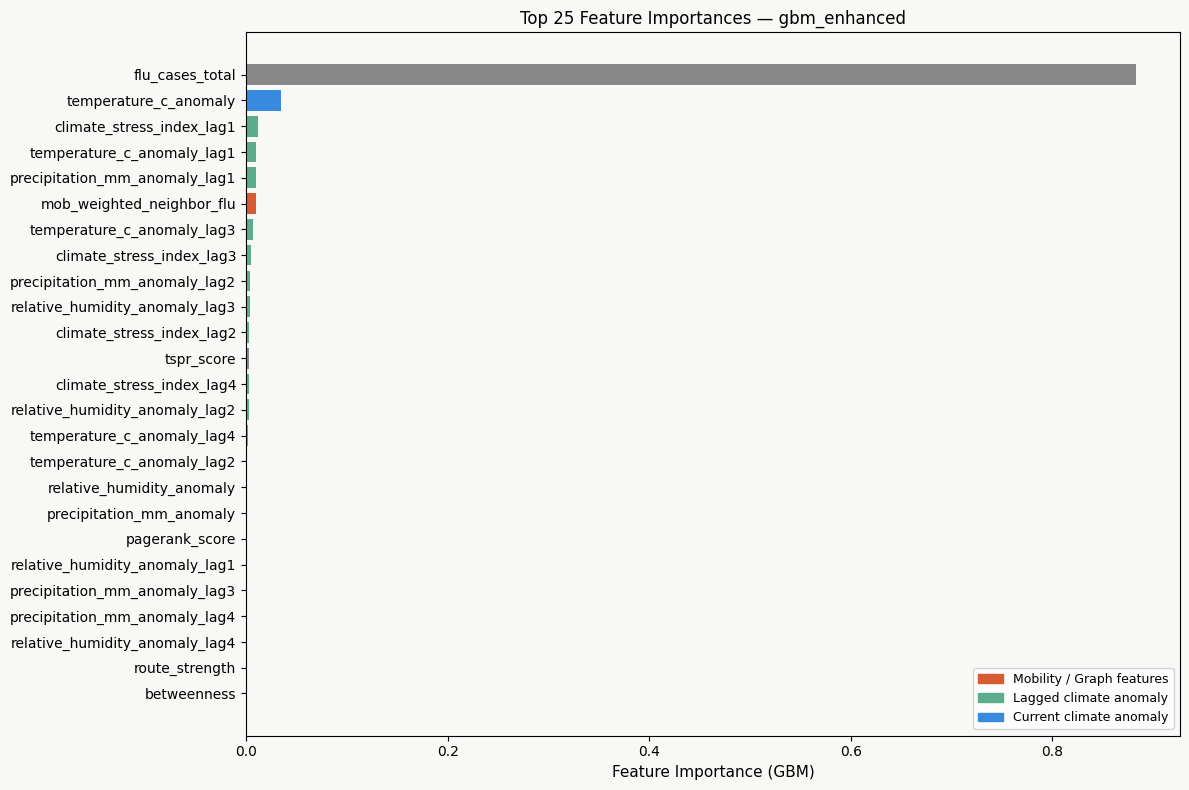

✓ Saved feature_importance.png

Mobility/Graph features total importance: 0.0103
Climate anomaly features total importance: 0.0796
→ Mobility adds 11.5% of explained importance


In [16]:
gbm_model = trained_models[best_gbm_key]['model']

if hasattr(gbm_model, 'feature_importances_'):
    feat_names = FEAT_ENH[:len(gbm_model.feature_importances_)]
    fi = pd.DataFrame({'feature': feat_names, 'importance': gbm_model.feature_importances_})
    fi = fi.sort_values('importance', ascending=False).head(25)

    # Color by feature type
    def feat_color(name):
        if 'mob' in name or 'pagerank' in name or 'betweenness' in name or 'degree' in name:
            return '#D85A30'  # mobility/graph features
        elif 'lag' in name:
            return '#5CAD8E'  # lag climate features
        elif 'anomaly' in name:
            return '#378ADD'  # current anomaly
        else:
            return '#888'

    fi_colors = [feat_color(n) for n in fi['feature']]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=fi_colors[::-1])
    ax.set_xlabel('Feature Importance (GBM)', fontsize=11)
    ax.set_title(f'Top 25 Feature Importances — {best_gbm_key}', fontsize=12)
    ax.set_facecolor('#f8f8f6')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#D85A30', label='Mobility / Graph features'),
        Patch(color='#5CAD8E', label='Lagged climate anomaly'),
        Patch(color='#378ADD', label='Current climate anomaly'),
    ], fontsize=9, loc='lower right')

    fig.patch.set_facecolor('#f8f8f6')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved feature_importance.png')

    mob_imp  = fi[fi['feature'].apply(lambda x: 'mob' in x or 'pagerank' in x)]['importance'].sum()
    clim_imp = fi[fi['feature'].apply(lambda x: 'anomaly' in x)]['importance'].sum()
    print(f'\nMobility/Graph features total importance: {mob_imp:.4f}')
    print(f'Climate anomaly features total importance: {clim_imp:.4f}')
    print(f'→ Mobility adds {mob_imp/(mob_imp+clim_imp)*100:.1f}% of explained importance')

## 4.8 Country Risk Ranking

Top 20 High-Risk Countries — Next 2 Weeks:
country_iso3  predicted_flu_next2w  composite_risk  risk_rank
         CHN           8604.066213        0.856554          1
         ESP            603.508607        0.427473          2
         DEU             56.939208        0.403971          3
         FRA            167.743280        0.323382          4
         ITA            407.540844        0.300235          5
         ARE             42.917947        0.197998          6
         RUS             15.599519        0.196739          7
         JPN            311.460189        0.176791          8
         AUS            217.362980        0.155082          9
         KOR            175.231874        0.127813         10
         NLD             17.636495        0.121435         11
         IND             21.697234        0.120607         12
         GRC             42.114160        0.113387         13
         SAU            105.705350        0.111160         14
         FIN            993

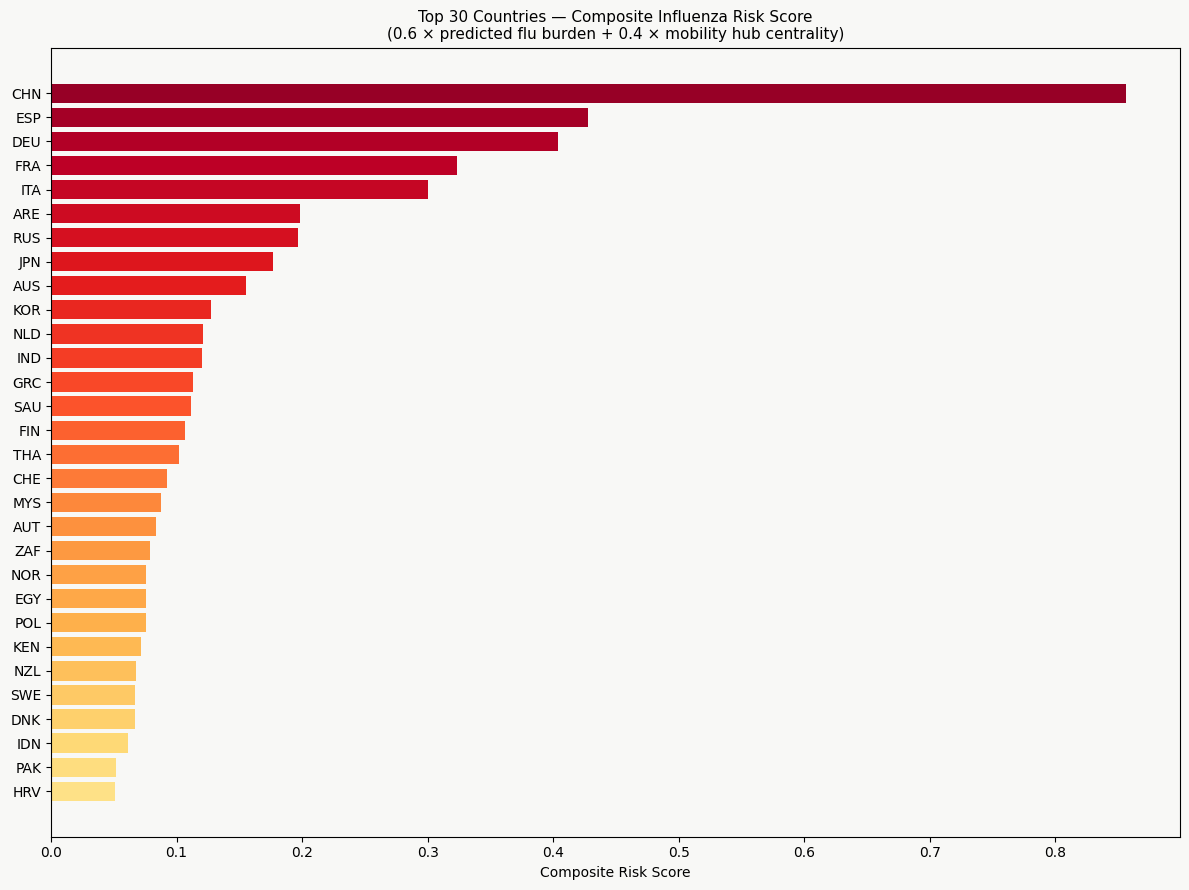

✓ Saved risk_ranking.png


In [17]:
latest = df_master.sort_values(['year','week']).groupby('country_iso3').last().reset_index()
avail  = [c for c in FEAT_ENH if c in latest.columns]

# Refit on all data
full_sub = df_master[avail+[TARGET]].dropna()
sc_full  = StandardScaler().fit(full_sub[avail].values)
gbm_full = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                      learning_rate=0.05, random_state=42)
gbm_full.fit(sc_full.transform(full_sub[avail].values), full_sub[TARGET].values)

X_lat  = sc_full.transform(latest[avail].fillna(0).values)
pred_r = np.maximum(gbm_full.predict(X_lat), 0)

risk_df = latest[['country_iso3']].copy()
risk_df['predicted_flu_next2w'] = pred_r
if 'pagerank_score' in latest.columns:
    pr_n   = latest['pagerank_score'].fillna(0) / (latest['pagerank_score'].max()+1e-9)
    flu_n  = pred_r / (pred_r.max()+1e-9)
    risk_df['composite_risk'] = 0.6*flu_n + 0.4*pr_n.values

score_col = 'composite_risk' if 'composite_risk' in risk_df.columns else 'predicted_flu_next2w'
risk_df = risk_df.sort_values(score_col, ascending=False).reset_index(drop=True)
risk_df['risk_rank'] = risk_df.index + 1

print('Top 20 High-Risk Countries — Next 2 Weeks:')
print(risk_df.head(20).to_string(index=False))

# Risk plot
top30 = risk_df.head(30)
fig, ax = plt.subplots(figsize=(12, 9))
palette = plt.cm.YlOrRd(np.linspace(0.2, 0.95, len(top30)))
ax.barh(top30['country_iso3'][::-1], top30[score_col][::-1], color=palette)
ax.set_title('Top 30 Countries — Composite Influenza Risk Score\n(0.6 × predicted flu burden + 0.4 × mobility hub centrality)',
             fontsize=11)
ax.set_xlabel('Composite Risk Score')
ax.set_facecolor('#f8f8f6'); fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'risk_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved risk_ranking.png')

## 4.9 Baseline vs Enhanced — Improvement Analysis

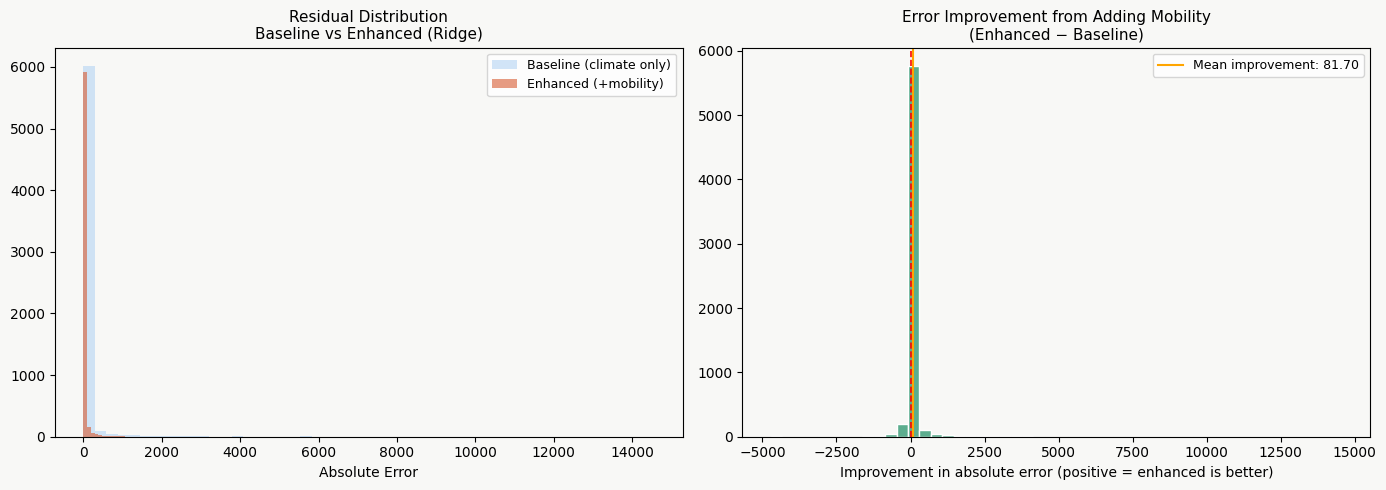

% of test records where enhanced model is better: 86.7%
Mean error reduction from adding mobility:        81.70 cases
✓ Saved mobility_improvement.png


In [18]:
# Residual comparison: does mobility help on high-traffic countries?
if 'ridge_baseline' in trained_models and 'ridge_enhanced' in trained_models:
    base_m = trained_models['ridge_baseline']
    enh_m  = trained_models['ridge_enhanced']

    # Align test sets (take intersection)
    te_b_aligned = te_b.copy().reset_index(drop=True)
    te_e_aligned = te_e.copy().reset_index(drop=True)
    common_len = min(len(base_m['pred']), len(enh_m['pred']))

    residuals_base = np.abs(base_m['actual'][:common_len] - base_m['pred'][:common_len])
    residuals_enh  = np.abs(enh_m['actual'][:common_len]  - enh_m['pred'][:common_len])
    improvement    = residuals_base - residuals_enh

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: residual distribution
    axes[0].hist(residuals_base, bins=50, alpha=0.6, color='#B5D4F4', label='Baseline (climate only)')
    axes[0].hist(residuals_enh,  bins=50, alpha=0.6, color='#D85A30', label='Enhanced (+mobility)')
    axes[0].set_xlabel('Absolute Error')
    axes[0].set_title('Residual Distribution\nBaseline vs Enhanced (Ridge)', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].set_facecolor('#f8f8f6')

    # Right: improvement histogram
    axes[1].hist(improvement, bins=50, color='#5CAD8E', edgecolor='white')
    axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--')
    axes[1].axvline(improvement.mean(), color='orange', linewidth=1.5, linestyle='-',
                    label=f'Mean improvement: {improvement.mean():.2f}')
    axes[1].set_xlabel('Improvement in absolute error (positive = enhanced is better)')
    axes[1].set_title('Error Improvement from Adding Mobility\n(Enhanced − Baseline)', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].set_facecolor('#f8f8f6')

    for ax in axes: ax.figure.patch.set_facecolor('#f8f8f6')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'mobility_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()

    pct_improved = (improvement > 0).mean()
    print(f'% of test records where enhanced model is better: {pct_improved:.1%}')
    print(f'Mean error reduction from adding mobility:        {improvement.mean():.2f} cases')
    print(f'✓ Saved mobility_improvement.png')

## 4.10 Final Summary

In [19]:
results_df.to_parquet(OUTPUT_DIR+'model_results.parquet', index=False)
risk_df.to_parquet(OUTPUT_DIR+'country_risk_scores.parquet', index=False)

print('=' * 65)
print('PART 4 — COMPLETE OUTPUT SUMMARY')
print('=' * 65)
print()
print('📊 Evaluation metrics (all models):')
print(results_df[['model','MAE','RMSE','R2','Precision','Recall','F1']].to_string(index=False))
print()
print(f'🏆 Best model: {best_key}')
best_row = results_df.loc[results_df['model']==best_key].iloc[0]
print(f'   MAE={best_row.MAE}  RMSE={best_row.RMSE}  R²={best_row.R2}  F1={best_row.F1}')
print()
print('🗂 Files saved:')
print('   model_results.parquet        — all model metrics')
print('   country_risk_scores.parquet  — risk ranking')
print('   model_dashboard.png          — 6-panel evaluation dashboard')
print('   per_country_predictions.png  — 9-country time series')
print('   lag_effect_analysis.png      — climate lag effect')
print('   feature_importance.png       — GBM feature importance')
print('   risk_ranking.png             — top 30 risk countries')
print('   mobility_improvement.png     — baseline vs enhanced residuals')
print()
print('🔬 MoMD algorithms in this notebook:')
print('   Reservoir Sampling (Algorithm R)   — unbiased test set construction')
print('   Flajolet-Martin                    — distinct outbreak event estimation')
print('   Welford online algorithm            — streaming feature normalization')
print('   Johnson-Lindenstrauss projection   — dimensionality reduction')

PART 4 — COMPLETE OUTPUT SUMMARY

📊 Evaluation metrics (all models):
            model     MAE    RMSE      R2  Precision  Recall    F1
   ridge_baseline 126.510 568.238 -0.0095      0.376   0.996 0.545
   ridge_enhanced  36.690 193.950  0.8878      0.679   0.847 0.754
ridge_enhanced_jl  36.686 193.941  0.8878      0.679   0.847 0.753
     gbm_baseline 126.530 567.682 -0.0075      0.375   0.986 0.543
     gbm_enhanced  38.395 209.779  0.8688      0.854   0.881 0.868
  gbm_enhanced_jl  71.454 273.970  0.7762      0.471   0.879 0.614

🏆 Best model: ridge_enhanced
   MAE=36.69  RMSE=193.95  R²=0.8878  F1=0.754

🗂 Files saved:
   model_results.parquet        — all model metrics
   country_risk_scores.parquet  — risk ranking
   model_dashboard.png          — 6-panel evaluation dashboard
   per_country_predictions.png  — 9-country time series
   lag_effect_analysis.png      — climate lag effect
   feature_importance.png       — GBM feature importance
   risk_ranking.png             — top 30 

## 4.2b Walk-Forward Validation + LazyPredict (2025 Holdout)

Use TimeSeriesSplit on train+validation (years before 2025) for model comparison, then keep all 2025 data as the final untouched holdout test set.

In [20]:
# LazyPredict can fail if not installed in the current kernel environment
try:
    from lazypredict.Supervised import LazyRegressor
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lazypredict', '-q'])
    from lazypredict.Supervised import LazyRegressor

from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

# Keep 2025 as final holdout, and use pre-2025 data for walk-forward CV
split_sub = df_master[FEAT_ENH + [TARGET, 'country_iso3', 'year', 'week']].dropna().copy()
split_sub = split_sub.sort_values(['year', 'week', 'country_iso3']).reset_index(drop=True)

tv_df = split_sub[split_sub['year'] < 2025].copy()
holdout_df = split_sub[split_sub['year'] == 2025].copy()

if len(tv_df) < 500 or len(holdout_df) < 100:
    # Fallback if yearly split is sparse
    split_cut = int(len(split_sub) * 0.8)
    tv_df = split_sub.iloc[:split_cut].copy()
    holdout_df = split_sub.iloc[split_cut:].copy()

print('=== WALK-FORWARD SPLIT SUMMARY ===')
print(f'Train+Validation rows (pre-2025): {len(tv_df):,}')
print(f'Holdout test rows (2025):          {len(holdout_df):,}')
print(f'TV period: {(int(tv_df["year"].min()), int(tv_df["week"].min()))} -> {(int(tv_df["year"].max()), int(tv_df["week"].max()))}')
print(f'Test period: {(int(holdout_df["year"].min()), int(holdout_df["week"].min()))} -> {(int(holdout_df["year"].max()), int(holdout_df["week"].max()))}')

X_tv = tv_df[FEAT_ENH]
y_tv = tv_df[TARGET]
X_holdout = holdout_df[FEAT_ENH]
y_holdout = holdout_df[TARGET]

# Walk-forward validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
fold_rows = []
metric_acc = defaultdict(list)

for fold_i, (tr_idx, va_idx) in enumerate(tscv.split(X_tv), start=1):
    X_tr_fold = X_tv.iloc[tr_idx]
    y_tr_fold = y_tv.iloc[tr_idx]
    X_va_fold = X_tv.iloc[va_idx]
    y_va_fold = y_tv.iloc[va_idx]

    lazy_reg = LazyRegressor(verbose=0, ignore_warnings=True, predictions=False)
    fold_res, _ = lazy_reg.fit(X_tr_fold, X_va_fold, y_tr_fold, y_va_fold)
    fold_res = fold_res.reset_index(names='model')
    fold_res['fold'] = fold_i
    fold_rows.append(fold_res)

    for _, r in fold_res.iterrows():
        model_name = str(r['model'])
        metric_acc[(model_name, 'R-Squared')].append(float(r.get('R-Squared', np.nan)))
        metric_acc[(model_name, 'RMSE')].append(float(r.get('RMSE', np.nan)))
        metric_acc[(model_name, 'MAE')].append(float(r.get('MAE', np.nan)))

    print(f'Fold {fold_i}/{n_splits}: train={len(tr_idx):,}, val={len(va_idx):,}, models={len(fold_res):,}')

lazy_cv_all = pd.concat(fold_rows, ignore_index=True)

# Aggregate metrics across folds
rows = []
models_seen = sorted({m for (m, met) in metric_acc.keys() if met == 'R-Squared'})
for m in models_seen:
    r2_vals = np.array(metric_acc.get((m, 'R-Squared'), [np.nan]), dtype=float)
    rmse_vals = np.array(metric_acc.get((m, 'RMSE'), [np.nan]), dtype=float)
    mae_vals = np.array(metric_acc.get((m, 'MAE'), [np.nan]), dtype=float)
    rows.append({
        'model': m,
        'cv_R2_mean': np.nanmean(r2_vals),
        'cv_R2_std': np.nanstd(r2_vals),
        'cv_RMSE_mean': np.nanmean(rmse_vals),
        'cv_MAE_mean': np.nanmean(mae_vals),
        'n_folds': int(np.sum(~np.isnan(r2_vals)))
    })

lazy_cv_summary = pd.DataFrame(rows).sort_values(['cv_R2_mean', 'cv_RMSE_mean'], ascending=[False, True])
print('\nTop models by walk-forward CV:')
display(lazy_cv_summary.head(15))

# Save outputs
lazy_cv_all.to_parquet(OUTPUT_DIR + 'lazy_regressor_walkforward_all_folds.parquet', index=False)
lazy_cv_summary.to_parquet(OUTPUT_DIR + 'lazy_regressor_walkforward_summary.parquet', index=False)
print('Saved: lazy_regressor_walkforward_all_folds.parquet')
print('Saved: lazy_regressor_walkforward_summary.parquet')

# Optional: evaluate best CV model class on holdout if available in LazyPredict defaults
best_model_name = lazy_cv_summary.iloc[0]['model'] if len(lazy_cv_summary) else None
print(f'\nBest model by CV: {best_model_name}')
print('Final holdout remains untouched for downstream model evaluation in later sections.')

=== WALK-FORWARD SPLIT SUMMARY ===
Train+Validation rows (pre-2025): 6,295
Holdout test rows (2025):          6,293
TV period: (2024, 5) -> (2024, 52)
Test period: (2025, 1) -> (2025, 52)
Fold 1/5: train=1,050, val=1,049, models=44
Fold 2/5: train=2,099, val=1,049, models=44
Fold 3/5: train=3,148, val=1,049, models=44
Fold 4/5: train=4,197, val=1,049, models=44
Fold 5/5: train=5,246, val=1,049, models=44

Top models by walk-forward CV:


,model,cv_R2_mean,cv_R2_std,cv_RMSE_mean,cv_MAE_mean,n_folds
25,LassoLarsIC,0.896847,0.072362,87.254257,NaN,5
39,SGDRegressor,0.896193,0.070078,87.287483,NaN,5
38,RidgeCV,0.896072,0.072274,87.551971,NaN,5
15,IncrementalRidge,0.896023,0.071932,87.457870,NaN,5
37,Ridge,0.896023,0.071932,87.457870,NaN,5
2,BayesianRidge,0.895966,0.071880,87.465354,NaN,5
41,TransformedTargetRegressor,0.895864,0.071789,87.478112,NaN,5
14,IncrementalLinearRegression,0.895864,0.071789,87.478112,NaN,5
26,LinearRegression,0.895864,0.071789,87.478112,NaN,5
19,Lars,0.895844,0.071489,87.430573,NaN,5


Saved: lazy_regressor_walkforward_all_folds.parquet
Saved: lazy_regressor_walkforward_summary.parquet

Best model by CV: LassoLarsIC
Final holdout remains untouched for downstream model evaluation in later sections.


## 4.2c Holdout Test Evaluation & Model Comparison

Train top models selected by walk-forward CV on all train+validation data, evaluate them on the 2025 holdout set, and visualize model comparison.

,model,R2_holdout,RMSE_holdout,MAE_holdout,n_test
2,RidgeCV,0.887934,193.860653,36.682513,6293
5,BayesianRidge,0.887864,193.921522,36.687652,6293
3,IncrementalRidge,0.887841,193.941487,36.689491,6293
4,Ridge,0.887841,193.941487,36.689491,6293
7,IncrementalLinearRegression,0.887830,193.950678,36.690326,6293
6,TransformedTargetRegressor,0.887830,193.950678,36.690326,6293
0,LassoLarsIC,0.887825,193.955288,36.359680,6293
1,SGDRegressor,0.886512,195.087321,37.184769,6293


Saved: lazy_regressor_holdout_comparison.parquet


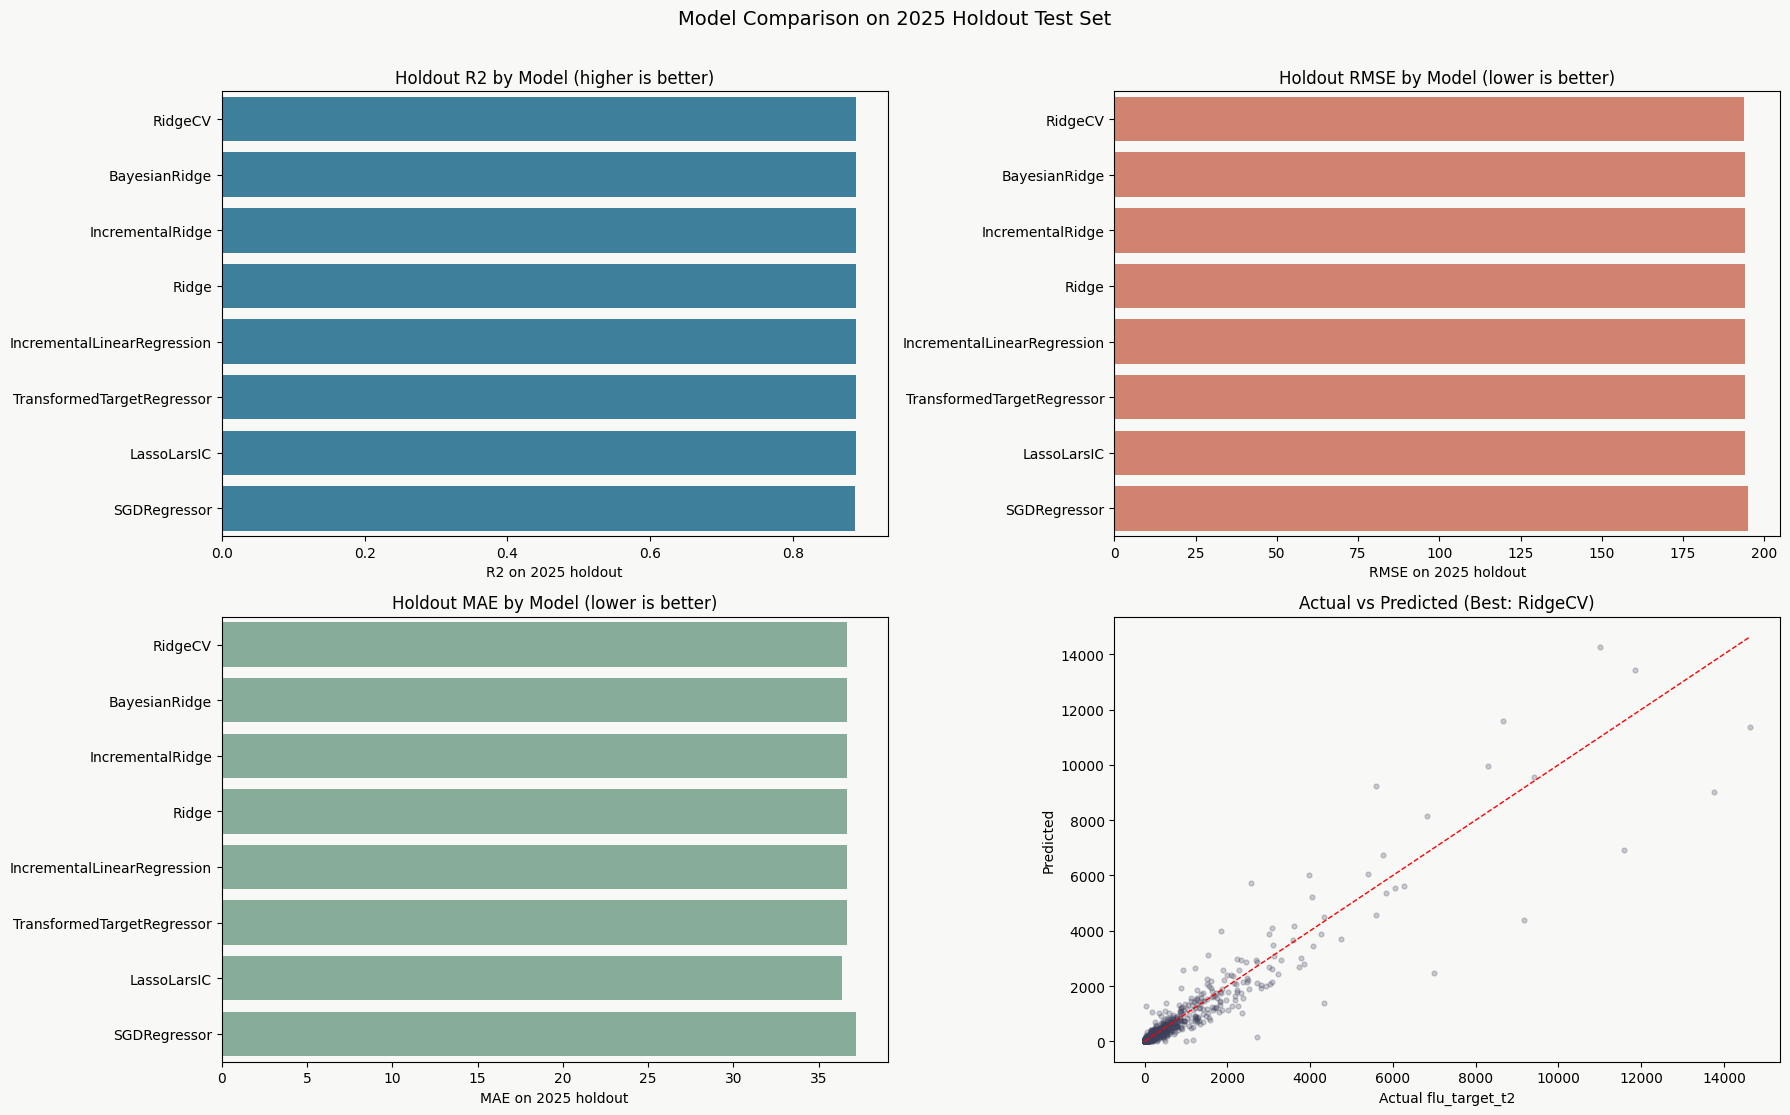

Saved: lazy_regressor_holdout_comparison.png


In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
import inspect

# Build model registry from LazyPredict defaults
try:
    from lazypredict.Supervised import REGRESSORS
except Exception:
    REGRESSORS = []

model_registry = {name: est for name, est in REGRESSORS}

def make_estimator(est_obj):
    """Return a fresh sklearn estimator instance from class or instance."""
    # Case 1: LazyPredict provides estimator class (most common)
    if inspect.isclass(est_obj):
        return est_obj()
    # Case 2: estimator instance -> clone for a fresh copy
    try:
        return clone(est_obj)
    except Exception:
        # Last fallback: return object as-is
        return est_obj

# Pick top models from CV summary
top_k = 8
candidate_models = lazy_cv_summary['model'].head(top_k).tolist() if 'lazy_cv_summary' in globals() else []

if len(candidate_models) == 0:
    raise RuntimeError('No candidate models found from walk-forward CV. Run Cell 10 first.')

holdout_rows = []
pred_store = {}

for model_name in candidate_models:
    if model_name not in model_registry:
        holdout_rows.append({
            'model': model_name,
            'R2_holdout': np.nan,
            'RMSE_holdout': np.nan,
            'MAE_holdout': np.nan,
            'n_test': int(len(y_holdout)),
            'error': 'Model not found in lazypredict.REGRESSORS'
        })
        continue
    try:
        est = make_estimator(model_registry[model_name])
        pipe = make_pipeline(StandardScaler(), est)
        pipe.fit(X_tv, y_tv)
        pred = np.maximum(pipe.predict(X_holdout), 0)

        mae = mean_absolute_error(y_holdout, pred)
        rmse = root_mean_squared_error(y_holdout, pred)
        r2 = r2_score(y_holdout, pred)

        holdout_rows.append({
            'model': model_name,
            'R2_holdout': float(r2),
            'RMSE_holdout': float(rmse),
            'MAE_holdout': float(mae),
            'n_test': int(len(y_holdout))
        })
        pred_store[model_name] = pred
    except Exception as e:
        holdout_rows.append({
            'model': model_name,
            'R2_holdout': np.nan,
            'RMSE_holdout': np.nan,
            'MAE_holdout': np.nan,
            'n_test': int(len(y_holdout)),
            'error': str(e)[:180]
        })

holdout_results = pd.DataFrame(holdout_rows).sort_values('R2_holdout', ascending=False, na_position='last')
display(holdout_results)

holdout_results.to_parquet(OUTPUT_DIR + 'lazy_regressor_holdout_comparison.parquet', index=False)
print('Saved: lazy_regressor_holdout_comparison.parquet')

# ---- Comparison plots ----
plot_df = holdout_results.dropna(subset=['R2_holdout', 'RMSE_holdout', 'MAE_holdout']).copy()
plot_df = plot_df.head(8)

if len(plot_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 11))
    fig.patch.set_facecolor('#f8f8f6')

    # 1) Holdout R2
    ax = axes[0, 0]
    sns.barplot(data=plot_df, y='model', x='R2_holdout', color='#2E86AB', ax=ax)
    ax.set_title('Holdout R2 by Model (higher is better)')
    ax.set_xlabel('R2 on 2025 holdout'); ax.set_ylabel('')
    ax.set_facecolor('#f8f8f6')

    # 2) Holdout RMSE
    ax = axes[0, 1]
    sns.barplot(data=plot_df, y='model', x='RMSE_holdout', color='#E07A5F', ax=ax)
    ax.set_title('Holdout RMSE by Model (lower is better)')
    ax.set_xlabel('RMSE on 2025 holdout'); ax.set_ylabel('')
    ax.set_facecolor('#f8f8f6')

    # 3) Holdout MAE
    ax = axes[1, 0]
    sns.barplot(data=plot_df, y='model', x='MAE_holdout', color='#81B29A', ax=ax)
    ax.set_title('Holdout MAE by Model (lower is better)')
    ax.set_xlabel('MAE on 2025 holdout'); ax.set_ylabel('')
    ax.set_facecolor('#f8f8f6')

    # 4) Actual vs Predicted for best model
    best_model_holdout = plot_df.iloc[0]['model']
    best_pred = pred_store.get(best_model_holdout, None)
    ax = axes[1, 1]
    if best_pred is not None:
        ax.scatter(y_holdout, best_pred, alpha=0.25, s=12, color='#3D405B')
        max_v = float(max(np.max(y_holdout), np.max(best_pred)))
        ax.plot([0, max_v], [0, max_v], '--', color='red', linewidth=1)
        ax.set_title(f'Actual vs Predicted (Best: {best_model_holdout})')
        ax.set_xlabel('Actual flu_target_t2'); ax.set_ylabel('Predicted')
    else:
        ax.text(0.5, 0.5, 'No prediction available', ha='center', va='center')
    ax.set_facecolor('#f8f8f6')

    plt.suptitle('Model Comparison on 2025 Holdout Test Set', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'lazy_regressor_holdout_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: lazy_regressor_holdout_comparison.png')
else:
    print('No valid holdout metrics to plot.')
    if 'error' in holdout_results.columns:
        print('\nCommon errors from failed models:')
        display(holdout_results[['model', 'error']].dropna())